In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

2025-12-24 03:25:50.740543: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-24 03:25:51.975983: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-24 03:25:56.908964: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [ ]:
X_train.shape

(60000, 28, 28)

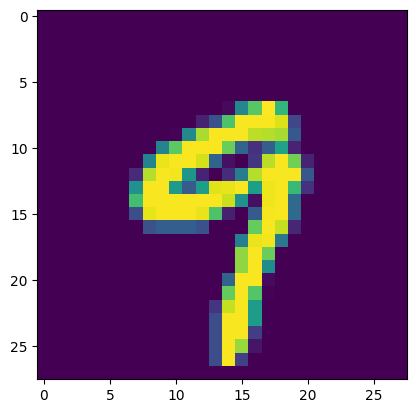

In [ ]:
plt.imshow(X_train[10023])

In [ ]:
y_train[10023]

np.uint8(9)

In [ ]:
X_train=X_train/255
X_test=X_test/255

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

## Model Building (ANN)

In [ ]:
model=Sequential()
model.add(Flatten(input_shape=(28,28))) # INPUT LAYER
model.add(Dense(128,activation="relu"))  # HIDDEN LAYER
model.add(Dense(64,activation="relu"))     # HIDDEN LAYER
model.add(Dense(10,activation="softmax")) # OUTPUT LAYER

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10, batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8752 - loss: 0.4218 - val_accuracy: 0.9639 - val_loss: 0.1170
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9668 - loss: 0.1079 - val_accuracy: 0.9667 - val_loss: 0.1075
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9791 - loss: 0.0692 - val_accuracy: 0.9737 - val_loss: 0.0816
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9842 - loss: 0.0515 - val_accuracy: 0.9740 - val_loss: 0.0843
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9865 - loss: 0.0419 - val_accuracy: 0.9777 - val_loss: 0.0777
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9898 - loss: 0.0327 - val_accuracy: 0.9742 - val_loss: 0.0930
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9908 - loss: 0.0283 - val_accuracy: 0.9766 - val_loss: 0.0813
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9923 - loss: 0.0227 - 

## Convolutional Neural Networks

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [ ]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

X_train=X_train/255
X_test=X_test/255

In [ ]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

### CNN Model

In [ ]:
model=Sequential()
# 1. Convolutional Layers
model.add(Conv2D(28,(3,3),input_shape=(28,28,1),activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(16,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))
# 2. Flatten Layers
model.add(Flatten())
# 3. ANN Layers
model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="sigmoid"))
model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.9910 - val_loss: 0.0308
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9979 - loss: 0.0065 - val_accuracy: 0.9903 - val_loss: 0.0338
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9978 - loss: 0.0064 - val_accuracy: 0.9892 - val_loss: 0.0416
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9976 - loss: 0.0075 - val_accuracy: 0.9925 - val_loss: 0.0315
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - accuracy: 0.9986 - loss: 0.0047 - val_accuracy: 0.9889 - val_loss: 0.0451
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9978 - loss: 0.0065 - val_accuracy: 0.9905 - val_loss: 0.0383
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.9906 - val_loss: 0.0375
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - accuracy: 0.9986 -

## ROC Curves

In [ ]:
import matplotlib.pyplot as plt

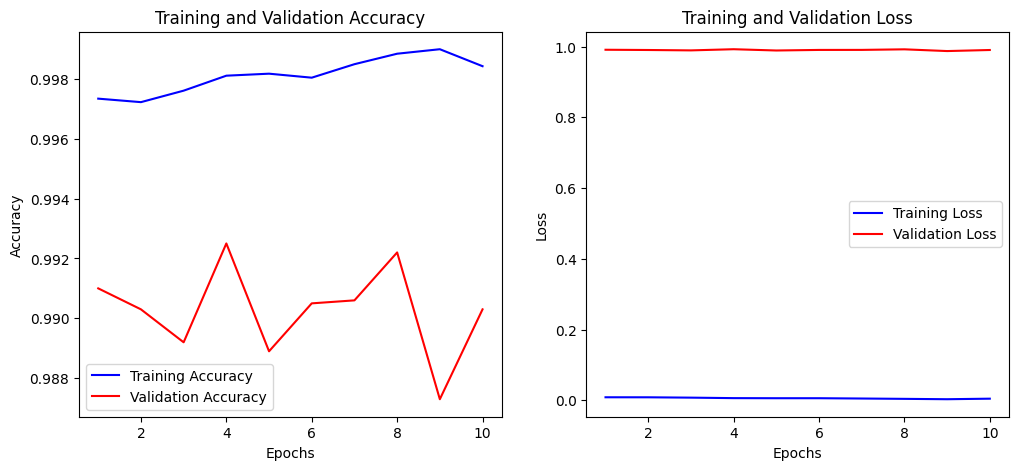

In [ ]:
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]

loss=history.history["loss"]
val_loss=history.history["val_loss"]

epochs=range(1,len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(epochs,acc,"b",label="Training Accuracy")
plt.plot(epochs,val_acc,"r",label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(122)
plt.plot(epochs,loss,"b",label="Training Loss")
plt.plot(epochs,val_acc,"r",label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
